# **Shredded Documents**

<div style="font-size: 14px; color: #6e8192; line-height: 1.5;">
  <div style="display: flex; align-items: center; gap: 5px; margin-bottom: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🎯</span>
    <span>AI National Olympiad, Summer Qualifier</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">👁️</span>
    <span>Computer Vision</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🏆</span>
    <span>100 points (30 + 10 + 25 + 25 + 10)</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🗓️</span>
    <span>May 2026</span>
  </div>
</div>

**Name:** [WRITE YOUR NAME HERE]

**Competitor ID (DOCK):** [WRITE YOUR COMPETITOR ID HERE]

## **Situation Report**

**Case number:** OSF-26-0520  
**Location:** Velmora, Meridian Islands  
**Suspected exchange date:** 2026-05-20  

Velmora is a canal city: with public archives, civic festivals, and a dense street camera network. A security validation lab reported that a sealed storage unit containing a powerful generative video model had been stolen. The model can synthesize convincing faces and voices, making it usable for fraud, blackmail, fake news footage, or simulated political incidents.

Intercepted fragments suggest that a hidden client used the codename **Dr. Schmertz**. The stolen model was passed between two suspects, then to a courier. Intelligence indicates the exchange took place on **2026-05-20** in **Old Velmora**. The mastermind may have watched from the crowd, disguised.

All persons, places, institutions, and events in the task are fictitious.

## **Task Description**

You are given three shredded documents and a set of CCTV footage. Your tasks: reconstruct the documents, extract the suspects' data from them, identify the people visible on CCTV using the provided recognition model, find the two suspects who conducted the exchange, then deduce who the mastermind is.

The task is divided into five sections:

1. Reconstruct the shredded briefing, the suspect list, and the citizen list. **(30 points)**
2. Extract the suspects' data and match them to citizen/class IDs. **(10 points)**
3. Run the citizen recognition network on the CCTV crops. **(25 points)**
4. Determine which two suspects carried out the exchange. **(25 points)**
5. Choose: **who is the mastermind?** **(10 points)**

Do not jump straight to visual inspection. The task rewards reproducible computer vision pipelines.

Detailed scoring rules can be found in the task description document (ShreddedDocuments.pdf).

## **Helpful Constraints for Pipeline Design**

- Each shredded strip is **20 px wide**.
- The barcode area is **44 px high**.
- The barcode contains **11 horizontal binary lines**, each approx. **4 px high**.
- Each document has a different background color.
- You are given a sample document with a barcode (`briefing_page1_with_barcode.png`).
- The barcode / artifact indicates which document the strip belongs to and where it fits in the reconstructed page.
- The barcode may be blurred.
- On CCTV, citizens always face left. No rotation.
- Citizen names (last + first name combination) are **unique**.
- Random citizens never appear close to each other on CCTV.
- The mastermind only appears in scenes where the relevant agents / suspects are also visible.

These are constraints, not solutions. Your implementation may take advantage of them.

## **Expected Folder Structure**

The `Download Dataset` cell below creates this structure. If the files are already in the working directory, the download is skipped.

```text
data/
  shreds/                          # 1922 shredded strips .png
  cctv/                            # CCTV images (.png) + bounding boxes (.csv)
  background_briefing.png
  background_suspect_list.png
  background_citizen_list.png
  briefing_page1_with_barcode.png  # example: reconstructed briefing with barcode
  best_citizen_face_model.pt       # citizen recognition model weights
```

CCTV CSV bounding box columns (`left, top, right, bottom`).

## **Useful Links**

- [PIL / Pillow documentation](https://pillow.readthedocs.io/)
- [NumPy documentation](https://numpy.org/doc/stable/)
- [pandas documentation](https://pandas.pydata.org/docs/)
- [PyTorch documentation](https://pytorch.org/docs/stable/index.html)
- [scikit-image documentation](https://scikit-image.org/docs/stable/)
- [OpenCV-Python tutorial](https://docs.opencv.org/master/d6/d00/tutorial_py_root.html)
- [pytesseract (OCR)](https://github.com/madmaze/pytesseract)

## **Required Imports**

For reproducibility, all randomness is tied to a single seed. The scorer is deterministic, so the same code yields the same score.

In [1]:
# ═══════════════════════════════════════════════════════════════════
# DO NOT MODIFY: With this seed you get the same result every
# time you re-run.
# ═══════════════════════════════════════════════════════════════════
import os
import math
import random
import re
import zipfile
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

# Optional, install separately if needed:
# import cv2
# import pytesseract

# --- Reproducibility: tie all randomness to a single seed ---
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## **Download Dataset**

We download three files from Google Drive: two zips with the `data/` folder contents and the citizen recognition model. Replace the `<FILE_ID>` placeholders with the IDs provided by the competition organizers.

The cell runs safely in Google Colab and locally. If `gdown` is not installed, it installs it automatically; if unsuccessful (e.g., in an offline environment), it prints the manual download URLs. If the `data/` folder already exists with the expected content, the download is skipped.

In [2]:
import os
import subprocess
import sys
import zipfile
from pathlib import Path

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

# We download two zips and extract them under data/, plus the model file
# directly to data/best_citizen_face_model.pt. The FILE_IDs are given by the organizers.
FILES = {
    "data_documents.zip":         "1jG4yj_SM5Zw-697iRMHKWKkvmI10DrLq",   # shreds/ + background_*.png + briefing_*.png
    "data_cctv.zip":              "1EBQ84SY8Cgumz8AGNNA1vBXa760BGYtT",   # cctv/ images and csvs
    "best_citizen_face_model.pt": "13iu5uFyXk56-jgemHZxgmojsg18WoTOi",   # citizen recognition model
}

EXTRACT_TARGETS = {
    "data_documents.zip": DATA_DIR,
    "data_cctv.zip":      DATA_DIR,
}

MOVE_TARGETS = {
    "best_citizen_face_model.pt": DATA_DIR / "best_citizen_face_model.pt",
}

# A sentinel for the three separate download sources: if all three exist,
# data/ is considered complete. background_*.png would be redundant,
# because they come from the same zip as shreds/.
SENTINELS = [
    DATA_DIR / "shreds",
    DATA_DIR / "cctv",
    DATA_DIR / "best_citizen_face_model.pt",
]

if all(p.exists() for p in SENTINELS):
    print("data/ folder already shows expected structure, skipping download.")
else:
    try:
        import gdown  # type: ignore
    except ImportError:
        try:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
            import gdown  # type: ignore
        except Exception:
            gdown = None  # type: ignore

    if gdown is None:
        print("gdown not available. Download the following files manually into the working directory:\n")
        for name, file_id in FILES.items():
            print(f"  https://drive.google.com/uc?id={file_id}  ->  {name}")
    else:
        for name, file_id in FILES.items():
            if Path(name).exists():
                print(f"  {name} already exists, skipping.")
                continue
            try:
                gdown.download(id=file_id, output=name, quiet=False)
            except Exception as e:
                print(f"  Failed to download {name}: {e}")
                print(f"  manual download: https://drive.google.com/uc?id={file_id}")

        # Extract into target folders
        for zip_name, target in EXTRACT_TARGETS.items():
            if not Path(zip_name).exists():
                continue
            print(f"Extracting: {zip_name} -> {target}/")
            with zipfile.ZipFile(zip_name, "r") as zf:
                zf.extractall(target)

        # Move model file under data/
        for src_name, dst in MOVE_TARGETS.items():
            if Path(src_name).exists() and not dst.exists():
                Path(src_name).rename(dst)

print('Done. Contents:')
for p in SENTINELS:
    print(f"  {p}: {'OK' if p.exists() else 'MISSING'}")

Downloading...
From: https://drive.google.com/uc?id=1jG4yj_SM5Zw-697iRMHKWKkvmI10DrLq
To: c:\Users\raian\source\repos\AI\IOAI_prep\hungary\2026\detective\data_documents.zip
100%|██████████| 11.6M/11.6M [00:01<00:00, 8.69MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1EBQ84SY8Cgumz8AGNNA1vBXa760BGYtT
From (redirected): https://drive.google.com/uc?id=1EBQ84SY8Cgumz8AGNNA1vBXa760BGYtT&confirm=t&uuid=74e67631-a3db-4b47-bd92-362b744481e4
To: c:\Users\raian\source\repos\AI\IOAI_prep\hungary\2026\detective\data_cctv.zip
100%|██████████| 2.10G/2.10G [03:22<00:00, 10.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=13iu5uFyXk56-jgemHZxgmojsg18WoTOi
To: c:\Users\raian\source\repos\AI\IOAI_prep\hungary\2026\detective\best_citizen_face_model.pt
100%|██████████| 1.02M/1.02M [00:00<00:00, 4.91MB/s]


Extracting: data_documents.zip -> data/
Extracting: data_cctv.zip -> data/
Done. Contents:
  data\shreds: OK
  data\cctv: OK
  data\best_citizen_face_model.pt: OK


## **Paths and Quick Check**

The cell below names the subdirectories and prints whether everything is in place. If something is `missing`, go back to the `Download Dataset` cell.

In [3]:
DATA_DIR      = Path('data')
SHRED_DIR     = DATA_DIR / 'shreds'
CCTV_DIR      = DATA_DIR / 'cctv'
MODEL_PATH    = DATA_DIR / 'best_citizen_face_model.pt'

for path in [SHRED_DIR, CCTV_DIR]:
    print(f"{path}: {'OK' if path.exists() else 'missing'}")
print(f"{MODEL_PATH}: {'OK' if MODEL_PATH.exists() else 'missing'}")

data\shreds: OK
data\cctv: OK
data\best_citizen_face_model.pt: OK


# **Section 1: Reconstruction of Shredded Documents** *(30 points)*

You are given images cut into strips. The original documents were cut vertically, then the order was shuffled.

Goal: reconstruct the three readable documents. From the reconstructed documents, you must be able to read the briefing, the suspect list, and the citizen list.

The sources can be separated by background color:

| Document | Expected strips | Pages | Background RGB |
|---|---:|---:|---|
| briefing | 62 | 1 | `(253, 247, 232)` |
| suspect list | 124 | 2 | `(253, 232, 232)` |
| citizen list | 1736 | 28 | `(235, 253, 232)` |

At the beginning of each strip there is a 44-pixel-high bit pattern artifact. Consider what 11 bits might encode.

## Submission Format

A CSV containing the first name, last name (including title), and date of birth (YYYY-MM-DD) of citizens with IDs 7, 12, 21, 35, and 42. In increasing order by ID.

E.g.,
```csv
ID,first_name,last_name,date_of_birth
7,Elek,Dr. Teszt,1888-08-01
12,Eszter,Vincs,1787-12-12
```

CSV with columns `id, first_name, last_name, date_of_birth`. Scoring is proportional: you get the proportion of correct cells out of 5 rows × 3 fields = 15 cells out of **30 points** (e.g., 10 correct fields → 20 points, 5 correct fields → 10 points). Case and trailing spaces are ignored.

In [4]:
# Read all shredded strips.
# This cell intentionally does not solve the reconstruction.

shred_paths = sorted(SHRED_DIR.glob("*.png"))
print("Number of strips:", len(shred_paths))

shreds = [Image.open(path).convert("RGB") for path in shred_paths]

if shreds:
    print("Example strip size:", shreds[0].size)
    plt.imshow(shreds[0])
    plt.axis("off")
else:
    print("No strips. Check the SHRED_DIR path.")

Number of strips: 1922
Example strip size: (20, 1798)


In [5]:
STRIP_WIDTH    = 20
BARCODE_HEIGHT = 44
BARCODE_BITS   = 11
BAR_HEIGHT     = 4

assert BARCODE_BITS * BAR_HEIGHT == BARCODE_HEIGHT

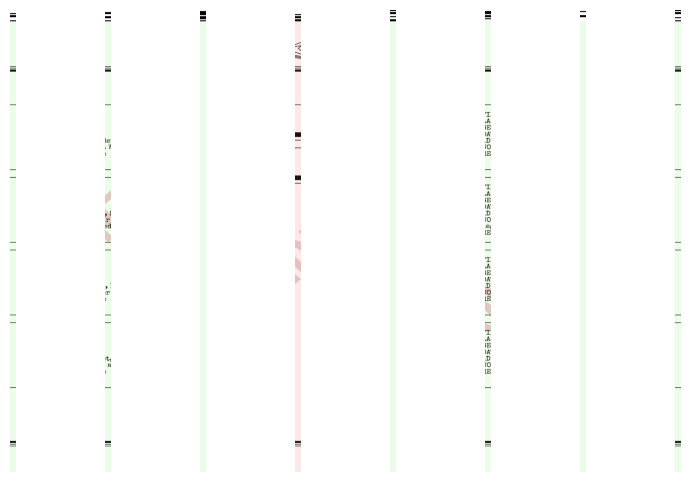

In [6]:
def show_strip_grid(strips, n=12):
    """Display the first n strips, without sorting logic."""
    if not strips:
        print("No strips to display.")
        return
    n = min(n, len(strips))
    fig, axes = plt.subplots(1, n, figsize=(1.2 * n, 6))
    if n == 1:
        axes = [axes]
    for ax, strip in zip(axes, strips[:n]):
        ax.imshow(strip)
        ax.axis("off")
    plt.show()

show_strip_grid(shreds, n=8)

## **Your code starts here**

In [27]:
shreds = [np.array(shred) for shred in shreds]
groups = {'briefing': [], 'suspect': [], 'citizen': []}
for shred in shreds:
    code = shred[:44, 0, 0][::-1]/255
    pos = sum(code[i*4]*2**i for i in range(0,11))

    background = shred[-1][0]
    if background[1] == 247:
        groups['briefing'].append((shred, pos))
    elif background[1] == 232:
        groups['suspect'].append((shred, pos))
    elif background[1] == 253:
        groups['citizen'].append((shred, pos))

In [31]:
groups['citizen'].sort(key=lambda x: x[1], reverse=True)
recon = np.concatenate([s for s,i in groups['citizen']], axis=1)
img = Image.fromarray(recon)
img.save('solved_data/citizen.png')

## **Checkpoint 1**

At this point you have reconstructed images of all three documents:

- briefing,
- suspect list,
- citizen list.

Do not hard-code visually read names. Structured data is needed for the following sections.

# **Section 2: Extracting Suspect Data and Matching to Citizen IDs** *(10 points)*

The reconstructed suspect list contains partially obscured records. The citizen list contains complete records.

Goal: determine which citizen/class ID belongs to each suspect.

The two lists are not symmetric: find a common, unique identifier field that links the partial records to the complete ones.

Do not enter the final suspect IDs into this starter notebook.

## Submission Format

CSV with columns `id, first_name, last_name, date_of_birth`, with **the complete record of all 7 suspects**. Perfect and complete match yields **10 points**, any missing field/row or discrepancy yields **0 points** (all-or-nothing).

## **Your code starts here**

In [ ]:
## TODO: logic for extracting suspect data and matching to citizen ID goes here.

# **Section 3: Running the Citizen Recognition Network on CCTV Crops** *(25 points)*

The CCTV images contain people. The task: cut out the detected person and pass it to the recognition network.

This section is **sensitive to preprocessing**. If you do not pass the image to the network in the format used during training, the model will confidently but incorrectly classify.

## What you need to consider

- What part of the bounding box the network expects.
- Input size, channel order, and value range.
- Relationship between the network output and citizen ID. If predictions seem systematically shifted relative to the citizen list, check the indexing.
- A visual smoke test always pays off: make sure the crop is actually what the network expects.

## Submission Format

CSV with column `id`: the set of citizen IDs who appear in those CCTV scenes where a suspect also appears (including or excluding the suspects: the scorer measures set overlap).

Scoring: 100% coverage **25 points**, at least 50% coverage **15 points**, otherwise **2 × correct IDs** points. If the submitted set size exceeds twice the ground truth size, **0 points** (anti-brute-force limit).

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

In [ ]:
def crop_for_network(frame: Image.Image, bbox, upper_fraction: float = 1 / 3) -> Image.Image:
    left, top, right, bottom = map(float, bbox)
    h = bottom - top
    crop_bottom = top + upper_fraction * h

    W, H = frame.size
    left  = max(0, min(W, int(round(left))))
    right = max(0, min(W, int(round(right))))
    top   = max(0, min(H, int(round(top))))
    crop_bottom = max(0, min(H, int(round(crop_bottom))))

    return frame.crop((left, top, right, crop_bottom)).convert("RGB")


def preprocess_for_network(crop: Image.Image) -> torch.Tensor:
    crop   = crop.convert("RGB").resize((64, 64))
    arr    = np.asarray(crop, dtype=np.float32) / 255.0
    tensor = torch.from_numpy(arr).permute(2, 0, 1)
    tensor = tensor.unsqueeze(0)
    tensor = (tensor - 0.5) / 0.5
    return tensor.to(DEVICE)

## **Your code starts here**

In [ ]:
## TODO: classification pipeline for CCTV crops goes here.

## **Checkpoint 2**

Before running through all CCTV images, manually verify a few network inputs.

A good crop shows the region the model was trained on. If it's too low, too wide, full body, rotated, or has wrong color order, expect unreliable predictions.

In [ ]:
def process_one_cctv_frame(model, image_path: Path, csv_path: Path) -> pd.DataFrame:
    """
    Generate predictions for one CCTV image.

    The returned table must contain at least:
    - image name,
    - bbox coordinates,
    - predicted citizen ID,
    - confidence.
    """
    frame = Image.open(image_path).convert("RGB")
    boxes = pd.read_csv(csv_path)[["left", "top", "right", "bottom"]].to_numpy()

    rows = []
    for bbox in boxes:
        crop = crop_for_network(frame, bbox)
        predicted_id, confidence = predict_citizen_id(model, crop)
        rows.append({
            "image": image_path.name,
            "left": bbox[0],
            "top": bbox[1],
            "right": bbox[2],
            "bottom": bbox[3],
            "predicted_id": predicted_id,
            "confidence": confidence,
        })

    return pd.DataFrame(rows)

# **Section 4: Identifying the Exchange** *(25 points)*

Now you must find out which two suspects carried out the exchange.

Start from the constraint in the constraints section that random citizens never appear close to each other on CCTV. Consider what a close pair indicates.

## Submission Format

CSV with header `id, first_name, last_name, date_of_birth` (the frontend pre-validation expects these 4 columns), with at most **2 rows**. More than 2 rows → **0 points**.

Two scoring modes, depending on what you put in the rows:

- **Only id filled** (the `first_name`, `last_name`, `date_of_birth` fields empty): correct id per row **5 points**, max **10 points**.
- **Complete record** (id + first_name + last_name filled, dob optional, scorer does not check it): both rows perfect **25 points**, one perfect **10 points**, neither **0 points**.

## **Your code starts here**

In [ ]:
## TODO: logic for identifying the suspect pair who carried out the exchange goes here.

# **Section 5: Finding the Returning Observer** *(10 points)*

The mastermind is not necessarily on the suspect list. The hidden observer appears in the relevant CCTV scenes.

A single appearance could easily be noise. You are looking for a cross-image, repeated presence pattern.

The final answer is intentionally not given in this notebook.

## Submission Format

CSV with header `id, first_name, last_name, date_of_birth` (the frontend pre-validation expects these 4 columns), with exactly **1 row**. More than 1 row → **0 points**.

Two scoring modes, depending on what you put in the row:

- **Only id filled** (the `first_name`, `last_name`, `date_of_birth` fields empty): correct id **5 points**.
- **Complete record** (id + first_name + last_name filled, dob optional, scorer does not check it): perfect complete match **10 points**, only id matches **5 points**, wrong id **0 points**.

## **Your code starts here**

In [ ]:
## TODO: logic for identifying the returning observer (mastermind) goes here.

---

## 🎉 Good luck!

The investigation consists of 5 sections, totaling 100 points. You have **10 submission attempts** per subtask (30 sec cooldown), and your best submission score counts.

You don't have to solve every section perfectly: partial scores add up. The sections build on each other (CCTV filtering requires the suspects, identifying the exchange and the mastermind requires CCTV predictions), but you can submit a partial solution for any section even if you only have partial results from the previous one.

---